# 02 距交割月份成交量与流动性

本 Notebook 复现论文 Table 1 Panel D 与 Table 2 的方法：构造距交割 0—5 个月的固定月份合约，基于真实日盘一分钟事实聚合五分钟区间，并按“交割月份”与“距交割月数”分别描述成交量和流动性。

本项只读取正式 silver，不调用 API，不写入 silver、gold 或项目缓存。AL、CU、FU 是论文品种；RB 始终标记为论文外扩展。FU 旧产品段与稳定重启段是两个独立研究序列。

## 1. 在做什么，以及经济意义

中国商品期货的个人投资者准入和临近交割保证金制度，会把交易活动推向较远月份。若不同到期距离的合约流动性系统性不同，直接选择近月或“主力连续”会改变零收益、有效价差和波动估计。

本项回答两个问题：

1. 每个自然交割月份的固定月份合约，在样本内距交割 0—5 个月窗口累计成交量是否存在季节差异？
2. Nearby、1、2、3、4、5 个月合约中，哪个到期距离在 Roll、零收益比例和 Amihud 三个维度上最流动？

这里的“最流动”对应三个指标更低：交易成本更低、价格更频繁变动、单位成交额承载的价格冲击更小。

## 2. 论文对应、公式与复现等级

- **Table 1 Panel D**：论文称其为“完整样本内各交割月份平均成交合约数”。本项目给出可审计定义：先对每个固定月份合约在距交割 0—5 个月研究窗口内汇总日盘 `volume`，再按自然交割月份对这些合约总量取均值；同时报告中位数、合约数、覆盖率和成交量份额。样本边界处合约可能只有部分窗口，结果不冒充论文 GTA 数值。
- **Table 2**：对每个合约日的五分钟流动性指标，按距交割月数汇总 Mean、Median、Stdev、Max。
- **Roll（1984）有效价差**：若相邻五分钟对数价格变化的样本协方差为负，`Roll = 2 * sqrt(-Cov(ΔlogP_n, ΔlogP_{n-1}))`；否则置 0。论文附录写作原始价格变化，但 Table 2 的 10^-3 量级及正文的五分钟收益描述表明其实证量纲是对数价格变化；本项目据此实现，并只在同一真实 Session 内形成相邻对。因此完整日有 45 - 3 = 42 对，不跨晨休或午休，也避免原始报价单位使 AL、CU、FU、RB 之间不可比。
- **Zeros**：`Zeros = zero-return intervals / N`。完整日固定 `N = 45`；以五分钟首尾价格严格相等判定零收益，避免浮点对数抵消误差。
- **Amihud（2002）**：对所有 `Money_n > 0` 的区间计算 `mean(|r_n| / Money_n)`。无有效分母的合约日记为缺失并报告覆盖。
- 与论文表格一致，展示时 Roll 乘 10^3，Amihud 乘 10^8，Zeros 保持 0—1 的比例。

**复现等级：论文方法框架复现。** 论文历史样本每天使用 48 个五分钟区间；本项目遵守冻结口径，只用当前正式湖的 225 个真实日盘交易分钟，形成 45 个五分钟区间，不虚构 10:15—10:30 晨休数据。

In [1]:
from __future__ import annotations

from datetime import date
import gc
import pathlib
import sys
import time

project_markers = [".git", ".env", "config/settings.py"]
current_path = pathlib.Path.cwd().resolve()

for candidate_root in [current_path, *current_path.parents]:
    if all((candidate_root / marker).exists() for marker in project_markers):
        sys.path.insert(0, str(candidate_root))
        project_root = candidate_root
        break
else:
    raise RuntimeError("未找到项目根目录")

expected_python = pathlib.Path(r"E:\anaconda3\envs\latitude\python.exe").resolve()
current_python = pathlib.Path(sys.executable).resolve()
assert current_python == expected_python, (
    f"必须使用 latitude 环境解释器 {expected_python}，实际为 {current_python}"
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
from IPython.display import Markdown, display

from config.data_contracts import (
    FUTURES_BAR_CALENDAR_SCHEMA,
    FUTURES_CONTRACT_CALENDAR_SCHEMA,
    FUTURES_MINUTE_SCHEMA,
    FUTURES_VARIETY_CALENDAR_SCHEMA,
    arrow_to_pandas,
    validate_arrow_table,
)
from config.notebook_schema_browser import display_schema_metadata
from config.settings import settings

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 200)

print(f"Python: {sys.executable}")
print(f"项目根目录: {project_root}")
print(f"正式湖仓根目录: {settings.futures_lake_root}")

Python: E:\anaconda3\envs\latitude\python.exe
项目根目录: E:\Latitude_Analytics_v2
正式湖仓根目录: E:\Latitude_Analytics_v2\03_Futures_Database\futures_lake


## 3. 开篇 Schema metadata 浏览器

直接参与本项的四张权威表依次为：品种交易日、合约 Session 日历、一分钟抓取/质量日历、一分钟事实。先浏览契约，再读取业务数据。

In [2]:
display_schema_metadata(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA,
        FUTURES_CONTRACT_CALENDAR_SCHEMA,
        FUTURES_BAR_CALENDAR_SCHEMA,
        FUTURES_MINUTE_SCHEMA,
    ]
)

英文表名,中文表名,字段数,主键,Hive 分区,Schema 版本
dim_futures_variety_calendar,期货品种交易日历维度表,8,"exchange_code,underlying_code,trading_date","exchange_code,year,month",1.2.0
dim_futures_contract_calendar,期货合约 Session 日历维度表,21,"contract_code,trading_date,session_number","exchange_code,year,month",1.2.0
dim_futures_bar_calendar,期货行情拉取与质检日历维度表,48,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",1.4.0
fact_futures_minute,国内期货合约一分钟行情事实表,17,"contract_code,bar_at","exchange_code,underlying_code,year,month",1.5.0


## 4. 参数、固定样本与代码步骤

代码从上到下分为八步：

1. 用 Schema metadata 打开四张表并核对物理字段；
2. 从品种交易日表冻结五个研究序列及端点；
3. 解析所有固定月份合约代码，构造距交割 0—5 月的合约—Session 网格；
4. 用一分钟 bar calendar 的正式完成证据筛选完整合约日；
5. 按“研究序列 × 年”直接过滤读取分钟事实，Session 内锚定首个收益并聚合五分钟；
6. 逐合约日计算 Roll、Zeros、Amihud 和日盘成交量；
7. 生成 Table 1 Panel D、Table 2 风格表与图；
8. 独立执行覆盖、边界、分母、有限性和缩放门禁。

In [3]:
exchange_code = "XSGE"
sample_start = date(2010, 1, 4)
sample_end = date(2026, 8, 28)

sample_spec_df = pd.DataFrame(
    [
        ("AL", "AL", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("CU", "CU", date(2010, 1, 4), date(2026, 8, 28), "论文品种"),
        ("FU_legacy", "FU", date(2010, 1, 4), date(2011, 9, 30), "论文品种：旧产品段"),
        ("FU_relaunched", "FU", date(2020, 1, 2), date(2026, 8, 28), "论文品种：稳定重启段"),
        ("RB", "RB", date(2010, 1, 4), date(2026, 8, 28), "论文外扩展品种"),
    ],
    columns=[
        "series_id",
        "underlying_code",
        "sample_start",
        "sample_end",
        "research_role",
    ],
)
sample_spec_df["sample_start"] = pd.to_datetime(sample_spec_df["sample_start"])
sample_spec_df["sample_end"] = pd.to_datetime(sample_spec_df["sample_end"])
series_order = sample_spec_df["series_id"].tolist()
display(sample_spec_df)

,series_id,underlying_code,sample_start,sample_end,research_role
0,AL,AL,2010-01-04,2026-08-28,论文品种
1,CU,CU,2010-01-04,2026-08-28,论文品种
2,FU_legacy,FU,2010-01-04,2011-09-30,论文品种：旧产品段
3,FU_relaunched,FU,2020-01-02,2026-08-28,论文品种：稳定重启段
4,RB,RB,2010-01-04,2026-08-28,论文外扩展品种


## 5. 直接 PyArrow 过滤读取与转换

表名、主键、分区列只从 Schema metadata 读取；字段类型和 nullable 只从权威 `pa.Schema` 读取。下面不建立局部 Schema 副本，也不读取无关列。

In [4]:
source_schema_by_role = {
    "variety_calendar": FUTURES_VARIETY_CALENDAR_SCHEMA,
    "contract_calendar": FUTURES_CONTRACT_CALENDAR_SCHEMA,
    "bar_calendar": FUTURES_BAR_CALENDAR_SCHEMA,
    "minute_fact": FUTURES_MINUTE_SCHEMA,
}
source_dataset_by_role = {}
source_metadata_by_role = {}
source_contract_audit_rows = []

for source_role, source_schema in source_schema_by_role.items():
    source_metadata = {
        key.decode("utf-8"): value.decode("utf-8")
        for key, value in source_schema.metadata.items()
    }
    table_name = source_metadata["table_name"]
    primary_key = source_metadata["primary_key"].split(",")
    partition_columns = source_metadata["partition_columns"].split(",")
    table_path = settings.futures_lake_root / "silver" / table_name
    partitioning = ds.partitioning(
        pa.schema(
            [source_schema.field(column_name) for column_name in partition_columns]
        ),
        flavor="hive",
    )
    source_dataset = ds.dataset(
        table_path,
        format="parquet",
        partitioning=partitioning,
    )

    physical_mismatches = []
    for expected_field in source_schema:
        actual_field = source_dataset.schema.field(expected_field.name)
        if (
            actual_field.type != expected_field.type
            or actual_field.nullable != expected_field.nullable
        ):
            physical_mismatches.append(
                {
                    "field": expected_field.name,
                    "expected_type": str(expected_field.type),
                    "actual_type": str(actual_field.type),
                    "expected_nullable": expected_field.nullable,
                    "actual_nullable": actual_field.nullable,
                }
            )
    if physical_mismatches:
        raise TypeError({table_name: physical_mismatches})

    source_dataset_by_role[source_role] = source_dataset
    source_metadata_by_role[source_role] = source_metadata
    source_contract_audit_rows.append(
        {
            "source_role": source_role,
            "table_name": table_name,
            "primary_key": ",".join(primary_key),
            "partition_columns": ",".join(partition_columns),
            "physical_mismatch_count": len(physical_mismatches),
        }
    )

source_contract_audit_df = pd.DataFrame(source_contract_audit_rows)
display(source_contract_audit_df)

,source_role,table_name,primary_key,partition_columns,physical_mismatch_count
0,variety_calendar,dim_futures_variety_calendar,"exchange_code,underlying_code,trading_date","exchange_code,year,month",0
1,contract_calendar,dim_futures_contract_calendar,"contract_code,trading_date,session_number","exchange_code,year,month",0
2,bar_calendar,dim_futures_bar_calendar,"bar_frequency,contract_code,trading_date,session_number","bar_frequency,exchange_code,year,month",0
3,minute_fact,fact_futures_minute,"contract_code,bar_at","exchange_code,underlying_code,year,month",0


In [5]:
trading_date_field = ds.field("trading_date")
underlying_field = ds.field("underlying_code")
base_filter = (
    (ds.field("exchange_code") == exchange_code)
    & (ds.field("year") >= sample_start.year)
    & (ds.field("year") <= sample_end.year)
)
main_series_filter = (
    underlying_field.isin(["AL", "CU", "RB"])
    & (trading_date_field >= pa.scalar(sample_start, type=pa.date32()))
    & (trading_date_field <= pa.scalar(sample_end, type=pa.date32()))
)
fu_series_filter = (
    (underlying_field == "FU")
    & (
        (
            (trading_date_field >= pa.scalar(date(2010, 1, 4), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2011, 9, 30), type=pa.date32()))
        )
        | (
            (trading_date_field >= pa.scalar(date(2020, 1, 2), type=pa.date32()))
            & (trading_date_field <= pa.scalar(date(2026, 8, 28), type=pa.date32()))
        )
    )
)
research_sample_filter = base_filter & (main_series_filter | fu_series_filter)

variety_columns = [
    "underlying_code",
    "exchange_code",
    "trading_date",
    "active_contract_count",
]
variety_projection_schema = pa.schema(
    [
        FUTURES_VARIETY_CALENDAR_SCHEMA.field(column_name)
        for column_name in variety_columns
    ]
)
variety_calendar_table = source_dataset_by_role["variety_calendar"].to_table(
    columns=variety_columns,
    filter=research_sample_filter,
)
validated_variety_calendar_table = validate_arrow_table(
    variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df = arrow_to_pandas(
    validated_variety_calendar_table,
    variety_projection_schema,
)
variety_calendar_df["trading_date"] = pd.to_datetime(
    variety_calendar_df["trading_date"]
)
variety_calendar_df = variety_calendar_df.sort_values(
    ["underlying_code", "trading_date"],
    ignore_index=True,
)

expected_sample_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    expected_series_df = variety_calendar_df.loc[
        (variety_calendar_df["underlying_code"] == sample_spec.underlying_code)
        & (variety_calendar_df["trading_date"] >= sample_spec.sample_start)
        & (variety_calendar_df["trading_date"] <= sample_spec.sample_end)
    ].copy()
    expected_series_df.insert(0, "series_id", sample_spec.series_id)
    expected_sample_pieces.append(expected_series_df)

expected_sample_df = pd.concat(
    expected_sample_pieces,
    ignore_index=True,
).sort_values(["series_id", "trading_date"], ignore_index=True)

display(
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(
        expected_trading_days="size",
        first_date="min",
        last_date="max",
    )
    .reset_index()
)

,series_id,expected_trading_days,first_date,last_date
0,AL,4045,2010-01-04,2026-08-28
1,CU,4045,2010-01-04,2026-08-28
2,FU_legacy,426,2010-01-04,2011-09-30
3,FU_relaunched,1614,2020-01-02,2026-08-28
4,RB,4045,2010-01-04,2026-08-28


In [6]:
contract_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "minute_count",
]
contract_projection_schema = pa.schema(
    [
        FUTURES_CONTRACT_CALENDAR_SCHEMA.field(column_name)
        for column_name in contract_columns
    ]
)
day_contract_filter = research_sample_filter & (
    ds.field("is_night_session") == False
)
contract_calendar_table = source_dataset_by_role["contract_calendar"].to_table(
    columns=contract_columns,
    filter=day_contract_filter,
)
validated_contract_calendar_table = validate_arrow_table(
    contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df = arrow_to_pandas(
    validated_contract_calendar_table,
    contract_projection_schema,
)
contract_calendar_df["trading_date"] = pd.to_datetime(
    contract_calendar_df["trading_date"]
)

contract_code_parts = contract_calendar_df["contract_code"].astype("string").str.extract(
    r"^([A-Z]+)(\d{4})\.([A-Z]+)$"
)
if not contract_code_parts.notna().all().all():
    invalid_contract_codes = contract_calendar_df.loc[
        contract_code_parts.isna().any(axis=1),
        "contract_code",
    ].drop_duplicates()
    raise ValueError(
        f"发现无法解析的固定月份合约代码: {invalid_contract_codes.tolist()}"
    )

contract_calendar_df["code_underlying"] = contract_code_parts[0]
contract_calendar_df["delivery_code"] = contract_code_parts[1]
contract_calendar_df["code_exchange"] = contract_code_parts[2]
contract_calendar_df["delivery_year"] = (
    2000 + contract_calendar_df["delivery_code"].str[:2].astype("int16")
)
contract_calendar_df["delivery_month"] = (
    contract_calendar_df["delivery_code"].str[2:].astype("int8")
)
contract_calendar_df["months_to_delivery"] = (
    (contract_calendar_df["delivery_year"] - contract_calendar_df["trading_date"].dt.year) * 12
    + contract_calendar_df["delivery_month"]
    - contract_calendar_df["trading_date"].dt.month
)

assert (
    contract_calendar_df["code_underlying"]
    == contract_calendar_df["underlying_code"]
).all()
assert (
    contract_calendar_df["code_exchange"]
    == contract_calendar_df["exchange_code"]
).all()
assert contract_calendar_df["delivery_month"].between(1, 12).all()

candidate_contract_calendar_df = contract_calendar_df.loc[
    contract_calendar_df["months_to_delivery"].between(0, 5)
].copy()

candidate_session_pieces = []
for sample_spec in sample_spec_df.itertuples(index=False):
    candidate_series_session_df = candidate_contract_calendar_df.loc[
        (
            candidate_contract_calendar_df["underlying_code"]
            == sample_spec.underlying_code
        )
        & (
            candidate_contract_calendar_df["trading_date"]
            >= sample_spec.sample_start
        )
        & (
            candidate_contract_calendar_df["trading_date"]
            <= sample_spec.sample_end
        )
    ].copy()
    candidate_series_session_df.insert(0, "series_id", sample_spec.series_id)
    candidate_session_pieces.append(candidate_series_session_df)

candidate_session_df = pd.concat(
    candidate_session_pieces,
    ignore_index=True,
).sort_values(
    [
        "series_id",
        "trading_date",
        "months_to_delivery",
        "contract_code",
        "session_number",
    ],
    ignore_index=True,
)

candidate_session_key = [
    "series_id",
    "contract_code",
    "trading_date",
    "session_number",
]
assert not candidate_session_df.duplicated(candidate_session_key).any()
assert not candidate_session_df["is_night_session"].any()

candidate_day_key = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "delivery_year",
    "delivery_month",
    "months_to_delivery",
]
candidate_contract_day_df = (
    candidate_session_df.groupby(
        candidate_day_key,
        observed=True,
        sort=True,
    )
    .agg(
        day_session_count=("session_number", "nunique"),
        day_minute_count=("minute_count", "sum"),
    )
    .reset_index()
)
display(
    candidate_contract_day_df.groupby(
        ["series_id", "months_to_delivery"],
        observed=True,
    )
    .agg(
        candidate_contract_days=("trading_date", "size"),
        unique_contracts=("contract_code", "nunique"),
        first_date=("trading_date", "min"),
        last_date=("trading_date", "max"),
    )
    .reset_index()
)

,series_id,months_to_delivery,candidate_contract_days,unique_contracts,first_date,last_date
0,AL,0,1964,200,2010-01-04,2026-08-17
1,AL,1,4045,200,2010-01-04,2026-08-28
2,AL,2,4045,200,2010-01-04,2026-08-28
3,AL,3,4045,200,2010-01-04,2026-08-28
4,AL,4,4045,200,2010-01-04,2026-08-28
5,AL,5,4045,200,2010-01-04,2026-08-28
6,CU,0,1964,200,2010-01-04,2026-08-17
7,CU,1,4045,200,2010-01-04,2026-08-28
8,CU,2,4045,200,2010-01-04,2026-08-28
9,CU,3,4045,200,2010-01-04,2026-08-28


In [7]:
bar_columns = [
    "bar_frequency",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "is_night_session",
    "is_fetch_required",
    "expected_bar_count",
    "is_fetch_completed",
    "actual_bar_count",
    "missing_bar_count",
    "quality_status",
]
bar_projection_schema = pa.schema(
    [FUTURES_BAR_CALENDAR_SCHEMA.field(column_name) for column_name in bar_columns]
)
day_bar_filter = (
    research_sample_filter
    & (ds.field("bar_frequency") == "1m")
    & (ds.field("is_night_session") == False)
)
bar_calendar_table = source_dataset_by_role["bar_calendar"].to_table(
    columns=bar_columns,
    filter=day_bar_filter,
)
validated_bar_calendar_table = validate_arrow_table(
    bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df = arrow_to_pandas(
    validated_bar_calendar_table,
    bar_projection_schema,
)
bar_calendar_df["trading_date"] = pd.to_datetime(
    bar_calendar_df["trading_date"]
)

bar_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
candidate_bar_session_df = candidate_session_df[
    [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "session_number",
        "delivery_year",
        "delivery_month",
        "months_to_delivery",
        "minute_count",
    ]
].merge(
    bar_calendar_df,
    on=bar_join_key,
    how="left",
    validate="one_to_one",
    indicator=True,
)
candidate_bar_session_df["eligible_session"] = (
    candidate_bar_session_df["_merge"].eq("both")
    & candidate_bar_session_df["is_fetch_required"].eq(True)
    & candidate_bar_session_df["is_fetch_completed"].eq(True)
    & candidate_bar_session_df["expected_bar_count"].eq(
        candidate_bar_session_df["actual_bar_count"]
    )
    & candidate_bar_session_df["missing_bar_count"].eq(0)
)

complete_contract_day_df = (
    candidate_bar_session_df.groupby(
        candidate_day_key,
        observed=True,
        sort=True,
    )
    .agg(
        candidate_session_count=("session_number", "nunique"),
        upstream_session_rows=("bar_frequency", "count"),
        eligible_session_count=("eligible_session", "sum"),
        expected_minute_rows=("expected_bar_count", "sum"),
        actual_minute_rows=("actual_bar_count", "sum"),
        missing_minute_rows=("missing_bar_count", "sum"),
    )
    .reset_index()
)
complete_contract_day_df["is_complete_contract_day"] = (
    complete_contract_day_df["candidate_session_count"].eq(3)
    & complete_contract_day_df["upstream_session_rows"].eq(3)
    & complete_contract_day_df["eligible_session_count"].eq(3)
    & complete_contract_day_df["expected_minute_rows"].eq(225)
    & complete_contract_day_df["actual_minute_rows"].eq(225)
    & complete_contract_day_df["missing_minute_rows"].eq(0)
)

expected_day_count_df = (
    expected_sample_df.groupby("series_id", observed=True)
    .size()
    .rename("expected_series_trading_days")
    .reset_index()
)
distance_coverage_df = (
    complete_contract_day_df.groupby(
        ["series_id", "months_to_delivery"],
        observed=True,
    )
    .agg(
        candidate_contract_days=("trading_date", "size"),
        complete_contract_days=("is_complete_contract_day", "sum"),
    )
    .reset_index()
    .merge(
        expected_day_count_df,
        on="series_id",
        validate="many_to_one",
    )
)
distance_coverage_df["upstream_complete_pct"] = (
    100
    * distance_coverage_df["complete_contract_days"]
    / distance_coverage_df["candidate_contract_days"]
)
distance_coverage_df["calendar_presence_pct"] = (
    100
    * distance_coverage_df["candidate_contract_days"]
    / distance_coverage_df["expected_series_trading_days"]
)
display(distance_coverage_df.round(4))

,series_id,months_to_delivery,candidate_contract_days,complete_contract_days,expected_series_trading_days,upstream_complete_pct,calendar_presence_pct
0,AL,0,1964,1964,4045,100.0,48.5538
1,AL,1,4045,4045,4045,100.0,100.0000
2,AL,2,4045,4045,4045,100.0,100.0000
3,AL,3,4045,4045,4045,100.0,100.0000
4,AL,4,4045,4045,4045,100.0,100.0000
5,AL,5,4045,4045,4045,100.0,100.0000
6,CU,0,1964,1964,4045,100.0,48.5538
7,CU,1,4045,4045,4045,100.0,100.0000
8,CU,2,4045,4045,4045,100.0,100.0000
9,CU,3,4045,4045,4045,100.0,100.0000


### 上游门禁的含义

`dim_futures_bar_calendar` 是分钟事实完成性与缺失数的权威证据。本 Notebook 信任生产者已证明的完整格点，只把 `is_fetch_required=True`、`is_fetch_completed=True`、预期数等于实际数且缺失数为 0 的三个日盘 Session 纳入聚合。随后对本地聚合所需的 Session 行数和槽位数做独立对齐检查，不重新审计整个正式湖的主键或采集历史。

In [8]:
complete_day_keys_df = complete_contract_day_df.loc[
    complete_contract_day_df["is_complete_contract_day"],
    candidate_day_key,
].copy()
complete_session_keys_df = candidate_bar_session_df.merge(
    complete_day_keys_df,
    on=candidate_day_key,
    how="inner",
    validate="many_to_one",
)
complete_session_keys_df = complete_session_keys_df.loc[
    complete_session_keys_df["eligible_session"]
].copy()
complete_session_keys_df["calendar_year"] = (
    complete_session_keys_df["trading_date"].dt.year.astype("int16")
)

minute_columns = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "bar_at",
    "open",
    "close",
    "volume",
    "money",
]
minute_projection_schema = pa.schema(
    [FUTURES_MINUTE_SCHEMA.field(column_name) for column_name in minute_columns]
)

minute_session_join_key = [
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
]
minute_session_context_columns = [
    "series_id",
    "contract_code",
    "exchange_code",
    "underlying_code",
    "trading_date",
    "session_number",
    "delivery_year",
    "delivery_month",
    "months_to_delivery",
    "expected_bar_count",
]
daily_liquidity_pieces = []
minute_read_audit_rows = []

for (
    series_id,
    calendar_year,
), partition_session_keys_df in complete_session_keys_df.groupby(
    ["series_id", "calendar_year"],
    observed=True,
    sort=True,
):
    partition_started_at = time.perf_counter()
    partition_session_keys_df = partition_session_keys_df[
        minute_session_context_columns
    ].drop_duplicates()
    assert not partition_session_keys_df.duplicated(
        minute_session_join_key
    ).any()

    underlying_codes = (
        partition_session_keys_df["underlying_code"].drop_duplicates().tolist()
    )
    assert len(underlying_codes) == 1
    underlying_code = underlying_codes[0]
    partition_first_date = partition_session_keys_df["trading_date"].min()
    partition_last_date = partition_session_keys_df["trading_date"].max()
    partition_contract_codes = (
        partition_session_keys_df["contract_code"].drop_duplicates().tolist()
    )

    minute_partition_filter = (
        (ds.field("exchange_code") == exchange_code)
        & (ds.field("underlying_code") == underlying_code)
        & (ds.field("year") == int(calendar_year))
        & ds.field("contract_code").isin(partition_contract_codes)
        & (
            ds.field("trading_date")
            >= pa.scalar(partition_first_date.date(), type=pa.date32())
        )
        & (
            ds.field("trading_date")
            <= pa.scalar(partition_last_date.date(), type=pa.date32())
        )
    )
    minute_partition_table = source_dataset_by_role["minute_fact"].to_table(
        columns=minute_columns,
        filter=minute_partition_filter,
    )
    validated_minute_partition_table = validate_arrow_table(
        minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df = arrow_to_pandas(
        validated_minute_partition_table,
        minute_projection_schema,
    )
    minute_partition_df["trading_date"] = pd.to_datetime(
        minute_partition_df["trading_date"]
    )

    selected_minute_df = minute_partition_df.merge(
        partition_session_keys_df,
        on=minute_session_join_key,
        how="inner",
        validate="many_to_one",
    )
    selected_minute_df = selected_minute_df.sort_values(
        minute_session_join_key + ["bar_at"],
        ignore_index=True,
    )
    for numeric_column in ["open", "close", "volume", "money"]:
        selected_minute_df[numeric_column] = pd.to_numeric(
            selected_minute_df[numeric_column]
        ).astype("float64")

    price_values = selected_minute_df[["open", "close"]].to_numpy()
    assert np.isfinite(price_values).all()
    assert (price_values > 0).all()
    assert not (
        selected_minute_df["volume"].dropna() < 0
    ).any()
    assert not (
        selected_minute_df["money"].dropna() < 0
    ).any()

    observed_session_rows_df = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )
        .size()
        .rename("observed_bar_count")
        .reset_index()
    )
    session_alignment_df = partition_session_keys_df[
        minute_session_join_key + ["expected_bar_count"]
    ].merge(
        observed_session_rows_df,
        on=minute_session_join_key,
        how="left",
        validate="one_to_one",
    )
    session_alignment_df["observed_bar_count"] = (
        session_alignment_df["observed_bar_count"].fillna(0).astype("int64")
    )
    misaligned_session_count = int(
        (
            session_alignment_df["expected_bar_count"]
            != session_alignment_df["observed_bar_count"]
        ).sum()
    )
    assert misaligned_session_count == 0

    selected_minute_df["minute_position_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        ).cumcount()
        + 1
    )
    selected_minute_df["previous_close_within_session"] = (
        selected_minute_df.groupby(
            minute_session_join_key,
            observed=True,
            sort=False,
        )["close"].shift()
    )
    first_minute_mask = selected_minute_df[
        "minute_position_within_session"
    ].eq(1)
    assert selected_minute_df.loc[
        first_minute_mask,
        "previous_close_within_session",
    ].isna().all()
    selected_minute_df["return_reference_price"] = (
        selected_minute_df["previous_close_within_session"].where(
            ~first_minute_mask,
            selected_minute_df["open"],
        )
    )
    selected_minute_df["minute_log_return"] = np.log(
        selected_minute_df["close"]
        / selected_minute_df["return_reference_price"]
    )
    selected_minute_df["five_minute_slot_within_session"] = (
        (
            selected_minute_df["minute_position_within_session"] - 1
        )
        // 5
        + 1
    )

    five_minute_key = [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delivery_year",
        "delivery_month",
        "months_to_delivery",
        "session_number",
        "five_minute_slot_within_session",
    ]
    five_minute_df = (
        selected_minute_df.groupby(
            five_minute_key,
            observed=True,
            sort=True,
        )
        .agg(
            five_minute_open=("return_reference_price", "first"),
            five_minute_close=("close", "last"),
            five_minute_volume=("volume", "sum"),
            volume_non_null_minutes=("volume", "count"),
            five_minute_money=("money", "sum"),
            money_non_null_minutes=("money", "count"),
            observed_minute_rows=("bar_at", "size"),
        )
        .reset_index()
    )
    five_minute_df.loc[
        five_minute_df["volume_non_null_minutes"].ne(5),
        "five_minute_volume",
    ] = np.nan
    five_minute_df.loc[
        five_minute_df["money_non_null_minutes"].ne(5),
        "five_minute_money",
    ] = np.nan
    assert five_minute_df["observed_minute_rows"].eq(5).all()

    five_minute_df["five_minute_return"] = np.log(
        five_minute_df["five_minute_close"]
        / five_minute_df["five_minute_open"]
    )
    five_minute_df["five_minute_log_price_change"] = (
        five_minute_df["five_minute_return"]
    )
    five_minute_df["is_zero_return"] = five_minute_df[
        "five_minute_close"
    ].eq(five_minute_df["five_minute_open"])
    five_minute_df["is_complete_volume_interval"] = (
        five_minute_df["volume_non_null_minutes"].eq(5)
    )
    five_minute_df["is_valid_amihud_interval"] = (
        five_minute_df["money_non_null_minutes"].eq(5)
        & five_minute_df["five_minute_money"].gt(0)
    )
    five_minute_df["amihud_component"] = np.where(
        five_minute_df["is_valid_amihud_interval"],
        five_minute_df["five_minute_return"].abs()
        / five_minute_df["five_minute_money"],
        np.nan,
    )

    daily_group_key = [
        "series_id",
        "contract_code",
        "exchange_code",
        "underlying_code",
        "trading_date",
        "delivery_year",
        "delivery_month",
        "months_to_delivery",
    ]
    daily_liquidity_df = (
        five_minute_df.groupby(
            daily_group_key,
            observed=True,
            sort=True,
        )
        .agg(
            day_session_count=("session_number", "nunique"),
            five_minute_interval_count=(
                "five_minute_slot_within_session",
                "size",
            ),
            zero_return_count=("is_zero_return", "sum"),
            valid_volume_interval_count=(
                "is_complete_volume_interval",
                "sum",
            ),
            daily_volume=("five_minute_volume", "sum"),
            valid_amihud_interval_count=(
                "is_valid_amihud_interval",
                "sum",
            ),
            amihud_illiquidity=("amihud_component", "mean"),
        )
        .reset_index()
    )
    daily_liquidity_df["zero_return_proportion"] = (
        daily_liquidity_df["zero_return_count"]
        / daily_liquidity_df["five_minute_interval_count"]
    )
    daily_liquidity_df.loc[
        daily_liquidity_df["valid_volume_interval_count"].ne(45),
        "daily_volume",
    ] = np.nan

    roll_session_group_key = daily_group_key + ["session_number"]
    five_minute_df["lagged_price_change_within_session"] = (
        five_minute_df.groupby(
            roll_session_group_key,
            observed=True,
            sort=False,
        )["five_minute_log_price_change"].shift()
    )
    roll_pair_df = five_minute_df.loc[
        five_minute_df["lagged_price_change_within_session"].notna(),
        daily_group_key
        + [
            "five_minute_log_price_change",
            "lagged_price_change_within_session",
        ],
    ].copy()
    roll_pair_df["price_change_cross_product"] = (
        roll_pair_df["five_minute_log_price_change"]
        * roll_pair_df["lagged_price_change_within_session"]
    )
    roll_sufficient_statistics_df = (
        roll_pair_df.groupby(
            daily_group_key,
            observed=True,
            sort=True,
        )
        .agg(
            roll_pair_count=("five_minute_log_price_change", "size"),
            current_change_sum=("five_minute_log_price_change", "sum"),
            lagged_change_sum=(
                "lagged_price_change_within_session",
                "sum",
            ),
            cross_product_sum=("price_change_cross_product", "sum"),
        )
        .reset_index()
    )
    roll_sufficient_statistics_df["roll_covariance"] = (
        roll_sufficient_statistics_df["cross_product_sum"]
        - (
            roll_sufficient_statistics_df["current_change_sum"]
            * roll_sufficient_statistics_df["lagged_change_sum"]
            / roll_sufficient_statistics_df["roll_pair_count"]
        )
    ) / (roll_sufficient_statistics_df["roll_pair_count"] - 1)
    roll_sufficient_statistics_df["roll_effective_spread"] = (
        2
        * np.sqrt(
            (-roll_sufficient_statistics_df["roll_covariance"]).clip(lower=0)
        )
    )

    daily_liquidity_df = daily_liquidity_df.merge(
        roll_sufficient_statistics_df[
            daily_group_key
            + [
                "roll_pair_count",
                "roll_covariance",
                "roll_effective_spread",
            ]
        ],
        on=daily_group_key,
        how="left",
        validate="one_to_one",
    )
    assert daily_liquidity_df["day_session_count"].eq(3).all()
    assert daily_liquidity_df["five_minute_interval_count"].eq(45).all()
    assert daily_liquidity_df["roll_pair_count"].eq(42).all()
    daily_liquidity_pieces.append(daily_liquidity_df)

    minute_read_audit_rows.append(
        {
            "series_id": series_id,
            "calendar_year": int(calendar_year),
            "partition_first_date": partition_first_date,
            "partition_last_date": partition_last_date,
            "contract_codes": len(partition_contract_codes),
            "raw_minute_rows_read": len(minute_partition_df),
            "selected_day_minute_rows": len(selected_minute_df),
            "expected_day_minute_rows": int(
                partition_session_keys_df["expected_bar_count"].sum()
            ),
            "session_alignment_failures": misaligned_session_count,
            "session_open_anchors": int(first_minute_mask.sum()),
            "five_minute_intervals": len(five_minute_df),
            "contract_days": len(daily_liquidity_df),
            "incomplete_volume_intervals": int(
                (~five_minute_df["is_complete_volume_interval"]).sum()
            ),
            "nonpositive_or_incomplete_money_intervals": int(
                (~five_minute_df["is_valid_amihud_interval"]).sum()
            ),
            "elapsed_seconds": time.perf_counter() - partition_started_at,
        }
    )

    del (
        minute_partition_table,
        validated_minute_partition_table,
        minute_partition_df,
        selected_minute_df,
        observed_session_rows_df,
        session_alignment_df,
        five_minute_df,
        roll_pair_df,
        roll_sufficient_statistics_df,
        daily_liquidity_df,
    )
    gc.collect()

daily_liquidity_df = pd.concat(
    daily_liquidity_pieces,
    ignore_index=True,
).sort_values(
    [
        "series_id",
        "trading_date",
        "months_to_delivery",
        "contract_code",
    ],
    ignore_index=True,
)
minute_read_audit_df = pd.DataFrame(minute_read_audit_rows)

display(
    minute_read_audit_df.groupby("series_id", observed=True)
    .agg(
        year_batches=("calendar_year", "size"),
        raw_minute_rows_read=("raw_minute_rows_read", "sum"),
        selected_day_minute_rows=("selected_day_minute_rows", "sum"),
        expected_day_minute_rows=("expected_day_minute_rows", "sum"),
        session_alignment_failures=("session_alignment_failures", "sum"),
        session_open_anchors=("session_open_anchors", "sum"),
        five_minute_intervals=("five_minute_intervals", "sum"),
        contract_days=("contract_days", "sum"),
        incomplete_volume_intervals=(
            "incomplete_volume_intervals",
            "sum",
        ),
        nonpositive_or_incomplete_money_intervals=(
            "nonpositive_or_incomplete_money_intervals",
            "sum",
        ),
        elapsed_seconds=("elapsed_seconds", "sum"),
    )
    .reset_index()
    .round(3)
)

,series_id,year_batches,raw_minute_rows_read,selected_day_minute_rows,expected_day_minute_rows,session_alignment_failures,session_open_anchors,five_minute_intervals,contract_days,incomplete_volume_intervals,nonpositive_or_incomplete_money_intervals,elapsed_seconds
0,AL,17,15856215,4992525,4992525,0,66567,998505,22189,0,45535,23.199
1,CU,17,15857340,4992525,4992525,0,66567,998505,22189,0,13931,23.693
2,FU_legacy,2,784575,442350,442350,0,5898,88470,1966,0,45624,1.488
3,FU_relaunched,7,5125995,1804950,1804950,0,24066,360990,8022,0,63063,7.933
4,RB,17,12522060,4992525,4992525,0,66567,998505,22189,0,352636,19.965


## 6. Table 1 Panel D 风格：自然交割月份成交量

`volume` 按正式分钟事实原单位相加，不应用合约乘数。每个固定月份合约只统计它在本项目 0—5 月窗口、固定样本端点和真实日盘中的成交量。先形成“合约总量”，再按交割月份跨年份合约取平均，避免用日数更多的月份直接支配均值。

In [9]:
contract_volume_df = (
    daily_liquidity_df.groupby(
        [
            "series_id",
            "underlying_code",
            "contract_code",
            "delivery_year",
            "delivery_month",
        ],
        observed=True,
        sort=True,
    )
    .agg(
        observed_contract_days=("trading_date", "nunique"),
        valid_volume_days=("daily_volume", "count"),
        observed_contract_volume=("daily_volume", "sum"),
    )
    .reset_index()
)
contract_volume_df["volume_day_coverage_pct"] = (
    100
    * contract_volume_df["valid_volume_days"]
    / contract_volume_df["observed_contract_days"]
)
contract_volume_df["complete_contract_volume"] = (
    contract_volume_df["observed_contract_volume"].where(
        contract_volume_df["valid_volume_days"].eq(
            contract_volume_df["observed_contract_days"]
        )
    )
)

table1_panel_d_df = (
    contract_volume_df.groupby(
        ["series_id", "delivery_month"],
        observed=True,
        sort=True,
    )
    .agg(
        delivery_contract_count=("contract_code", "size"),
        valid_contract_count=("complete_contract_volume", "count"),
        mean_contracts_traded=("complete_contract_volume", "mean"),
        median_contracts_traded=("complete_contract_volume", "median"),
        stdev_contracts_traded=("complete_contract_volume", "std"),
        month_total_volume=("complete_contract_volume", "sum"),
        mean_observed_contract_days=("observed_contract_days", "mean"),
        min_volume_day_coverage_pct=("volume_day_coverage_pct", "min"),
    )
    .reset_index()
)
table1_panel_d_df["volume_share_pct"] = (
    100
    * table1_panel_d_df["month_total_volume"]
    / table1_panel_d_df.groupby(
        "series_id",
        observed=True,
    )["month_total_volume"].transform("sum")
)

for series_id in series_order:
    display(Markdown(f"### {series_id}"))
    display(
        table1_panel_d_df.loc[
            table1_panel_d_df["series_id"] == series_id
        ].round(2)
    )

### AL

,series_id,delivery_month,delivery_contract_count,valid_contract_count,mean_contracts_traded,median_contracts_traded,stdev_contracts_traded,month_total_volume,mean_observed_contract_days,min_volume_day_coverage_pct,volume_share_pct
0,AL,1,18,18,3577924.44,3520698.0,2669873.42,64402640.0,101.72,100.0,9.02
1,AL,2,17,17,3450251.59,3295581.0,2375564.43,58654277.0,103.24,100.0,8.21
2,AL,3,17,17,3495357.82,3154362.0,2831193.97,59421083.0,103.71,100.0,8.32
3,AL,4,17,17,3187412.82,3235321.0,2073142.90,54186018.0,108.35,100.0,7.59
4,AL,5,17,17,3919693.24,4213177.0,2479738.57,66634785.0,107.41,100.0,9.33
5,AL,6,17,17,3746159.06,3926829.0,2218771.23,63684704.0,107.88,100.0,8.92
6,AL,7,17,17,3630368.47,4297823.0,2089293.53,61716264.0,109.35,100.0,8.64
7,AL,8,17,17,3232779.88,3699387.0,1691781.33,54957258.0,115.12,100.0,7.70
8,AL,9,17,17,3303256.53,3629154.0,1696237.83,56155361.0,114.06,100.0,7.86
9,AL,10,17,17,3603261.24,3278234.0,2090810.61,61255441.0,108.88,100.0,8.58


### CU

,series_id,delivery_month,delivery_contract_count,valid_contract_count,mean_contracts_traded,median_contracts_traded,stdev_contracts_traded,month_total_volume,mean_observed_contract_days,min_volume_day_coverage_pct,volume_share_pct
12,CU,1,18,18,5560561.56,3851298.5,5420288.33,100090108.0,101.72,100.0,9.22
13,CU,2,17,17,5088815.24,4562163.0,4063227.41,86509859.0,103.24,100.0,7.97
14,CU,3,17,17,5085873.29,4996328.0,3444295.01,86459846.0,103.71,100.0,7.97
15,CU,4,17,17,4216907.35,4048202.0,2032589.37,71687425.0,108.35,100.0,6.61
16,CU,5,17,17,5256554.65,4505712.0,2604168.38,89361429.0,107.41,100.0,8.24
17,CU,6,17,17,5131452.35,4654512.0,2337385.01,87234690.0,107.88,100.0,8.04
18,CU,7,17,17,5000420.76,4540882.0,2400312.28,85007153.0,109.35,100.0,7.83
19,CU,8,17,17,5344701.41,4260450.0,3255946.23,90859924.0,115.12,100.0,8.37
20,CU,9,17,17,6416887.24,3820174.0,5001396.27,109087083.0,114.06,100.0,10.05
21,CU,10,17,17,5631974.76,4443100.0,4332848.40,95743571.0,108.88,100.0,8.82


### FU_legacy

,series_id,delivery_month,delivery_contract_count,valid_contract_count,mean_contracts_traded,median_contracts_traded,stdev_contracts_traded,month_total_volume,mean_observed_contract_days,min_volume_day_coverage_pct,volume_share_pct
24,FU_legacy,1,1,1,2222348.0,2222348.0,NaN,2222348.0,102.0,100.0,8.90
25,FU_legacy,2,1,1,52.0,52.0,NaN,52.0,21.0,100.0,0.00
26,FU_legacy,3,2,2,2569382.0,2569382.0,3377860.41,5138764.0,65.5,100.0,20.58
27,FU_legacy,4,2,2,14688.0,14688.0,3230.06,29376.0,80.5,100.0,0.12
28,FU_legacy,5,2,2,4731526.0,4731526.0,3275943.69,9463052.0,89.5,100.0,37.89
29,FU_legacy,6,2,2,604198.0,604198.0,826358.93,1208396.0,98.5,100.0,4.84
30,FU_legacy,7,2,2,224983.0,224983.0,314434.83,449966.0,98.5,100.0,1.80
31,FU_legacy,8,2,2,7890.0,7890.0,7995.96,15780.0,105.0,100.0,0.06
32,FU_legacy,9,2,2,1670121.0,1670121.0,828871.98,3340242.0,104.5,100.0,13.38
33,FU_legacy,10,2,2,397649.0,397649.0,558853.36,795298.0,104.5,100.0,3.18


### FU_relaunched

,series_id,delivery_month,delivery_contract_count,valid_contract_count,mean_contracts_traded,median_contracts_traded,stdev_contracts_traded,month_total_volume,mean_observed_contract_days,min_volume_day_coverage_pct,volume_share_pct
36,FU_relaunched,1,7,7,27876799.29,20573586.0,21278670.76,195137595.0,88.71,100.0,20.44
37,FU_relaunched,2,7,7,1227541.57,43492.0,1999895.12,8592791.0,85.86,100.0,0.90
38,FU_relaunched,3,7,7,6765986.14,707057.0,8179101.18,47361903.0,87.29,100.0,4.96
39,FU_relaunched,4,7,7,579632.86,125751.0,886127.95,4057430.0,95.14,100.0,0.43
40,FU_relaunched,5,7,7,39790248.00,30616540.0,29192119.53,278531736.0,97.14,100.0,29.18
41,FU_relaunched,6,7,7,2246759.71,187009.0,3382766.75,15727318.0,96.86,100.0,1.65
42,FU_relaunched,7,7,7,3553285.00,282787.0,6678841.73,24872995.0,98.43,100.0,2.61
43,FU_relaunched,8,7,7,698411.43,160653.0,1032417.90,4888880.0,103.86,100.0,0.51
44,FU_relaunched,9,7,7,44997600.71,32500558.0,40881658.87,314983205.0,103.43,100.0,33.00
45,FU_relaunched,10,7,7,2882591.86,1217726.0,3834799.67,20178143.0,98.71,100.0,2.11


### RB

,series_id,delivery_month,delivery_contract_count,valid_contract_count,mean_contracts_traded,median_contracts_traded,stdev_contracts_traded,month_total_volume,mean_observed_contract_days,min_volume_day_coverage_pct,volume_share_pct
48,RB,1,18,18,1.137380e+08,106259938.5,74266126.68,2.047284e+09,101.72,100.0,32.35
49,RB,2,17,17,6.543309e+05,98984.0,1924776.97,1.112362e+07,103.24,100.0,0.18
50,RB,3,17,17,1.602428e+06,59262.0,2773370.64,2.724127e+07,103.71,100.0,0.43
51,RB,4,17,17,3.326987e+05,29444.0,855784.85,5.655877e+06,108.35,100.0,0.09
52,RB,5,17,17,1.129819e+08,90207915.0,68739776.83,1.920692e+09,107.41,100.0,30.35
53,RB,6,17,17,1.046366e+06,53940.0,3554755.19,1.778823e+07,107.88,100.0,0.28
54,RB,7,17,17,1.158709e+06,19881.0,2760653.17,1.969805e+07,109.35,100.0,0.31
55,RB,8,17,17,2.563274e+05,22123.0,806925.39,4.357565e+06,115.12,100.0,0.07
56,RB,9,17,17,8.714548e+05,634976.0,906298.47,1.481473e+07,114.06,100.0,0.23
57,RB,10,17,17,1.315864e+08,106348657.0,94515032.55,2.236969e+09,108.88,100.0,35.35


## 7. Table 2 风格：按距交割月数汇总日流动性

表中 Mean、Median、Stdev、Max 是“合约日”层面的描述统计。Nearby 对应 `months_to_delivery=0`。FU 若没有 Nearby 观测就保持缺失，不用其他月份替代。

In [10]:
daily_liquidity_df["roll_x1e3"] = (
    daily_liquidity_df["roll_effective_spread"] * 1e3
)
daily_liquidity_df["amihud_x1e8"] = (
    daily_liquidity_df["amihud_illiquidity"] * 1e8
)

metric_specifications = [
    ("Roll × 10^3", "roll_x1e3"),
    ("Zeros", "zero_return_proportion"),
    ("Amihud × 10^8", "amihud_x1e8"),
]
table2_summary_pieces = []

for measure_name, metric_column in metric_specifications:
    measure_summary_df = (
        daily_liquidity_df.groupby(
            ["series_id", "months_to_delivery"],
            observed=True,
            sort=True,
        )[metric_column]
        .agg(
            observations="count",
            Mean="mean",
            Median="median",
            Stdev="std",
            Max="max",
        )
        .reset_index()
    )
    measure_summary_df.insert(2, "measure", measure_name)
    table2_summary_pieces.append(measure_summary_df)

table2_tidy_df = pd.concat(
    table2_summary_pieces,
    ignore_index=True,
).sort_values(
    ["series_id", "months_to_delivery", "measure"],
    ignore_index=True,
)

table2_coverage_df = (
    daily_liquidity_df.groupby(
        ["series_id", "months_to_delivery"],
        observed=True,
        sort=True,
    )
    .agg(
        contract_days=("trading_date", "size"),
        roll_valid_days=("roll_effective_spread", "count"),
        zeros_valid_days=("zero_return_proportion", "count"),
        volume_valid_days=("daily_volume", "count"),
        amihud_valid_days=("amihud_illiquidity", "count"),
        valid_amihud_intervals=("valid_amihud_interval_count", "sum"),
        total_five_minute_intervals=(
            "five_minute_interval_count",
            "sum",
        ),
    )
    .reset_index()
)
table2_coverage_df["amihud_interval_coverage_pct"] = (
    100
    * table2_coverage_df["valid_amihud_intervals"]
    / table2_coverage_df["total_five_minute_intervals"]
)
display(table2_coverage_df.round(4))

for series_id in series_order:
    display(Markdown(f"### {series_id} — Table 2 风格"))
    series_table2_df = table2_tidy_df.loc[
        table2_tidy_df["series_id"] == series_id
    ].pivot(
        index="months_to_delivery",
        columns="measure",
        values=["Mean", "Median", "Stdev", "Max", "observations"],
    )
    display(series_table2_df.round(6))

,series_id,months_to_delivery,contract_days,roll_valid_days,zeros_valid_days,volume_valid_days,amihud_valid_days,valid_amihud_intervals,total_five_minute_intervals,amihud_interval_coverage_pct
0,AL,0,1964,1964,1964,1964,1962,77992,88380,88.2462
1,AL,1,4045,4045,4045,4045,4044,177823,182025,97.6915
2,AL,2,4045,4045,4045,4045,4044,180786,182025,99.3193
3,AL,3,4045,4045,4045,4045,4044,181307,182025,99.6055
4,AL,4,4045,4045,4045,4045,4044,177719,182025,97.6344
5,AL,5,4045,4045,4045,4045,4044,157343,182025,86.4403
6,CU,0,1964,1964,1964,1964,1963,85936,88380,97.2347
7,CU,1,4045,4045,4045,4045,4044,181475,182025,99.6978
8,CU,2,4045,4045,4045,4045,4044,181668,182025,99.8039
9,CU,3,4045,4045,4045,4045,4044,181788,182025,99.8698


### AL — Table 2 风格

Mean                              Median                               Stdev                                 Max                    observations                    
measure            Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3 Zeros Amihud × 10^8 Roll × 10^3   Zeros
months_to_delivery                                                                                                                                                                              
0                       0.016402    0.456422  0.343200      0.011293    0.288402  0.311111      0.017140    0.694420  0.186907      0.263504   13.346236   1.0        1962.0      1964.0  1964.0
1                       0.008115    0.428015  0.250306      0.002037    0.330051  0.222222      0.014585    0.495384  0.157149      0.181297    8.862678   1.0        4044.0      4045.0  4045.0
2                       0.002927    0.439972  0.224145      0.000709    0.365263  0.200000      0.005987    0.472770  0.136857      0.098642    3.843855   1.0        4044.0      4045.0  4045.0
3                       0.002812    0.423224  0.224810      0.001913    0.350901  0.200000      0.003092    0.466286  0.127264      0.036033    7.439120   1.0        4044.0      4045.0  4045.0
4                       0.012576    0.416711  0.241967      0.007445    0.334570  0.222222      0.015703    0.475515  0.144857      0.211631    7.698959   1.0        4044.0      4045.0  4045.0
5                       0.071874    0.431245  0.319868      0.038543    0.315871  0.266667      0.106546    0.517452  0.203148      2.990533    6.201670   1.0        4044.0      4045.0  4045.0

### CU — Table 2 风格

Mean                              Median                               Stdev                                 Max                    observations                    
measure            Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3 Zeros Amihud × 10^8 Roll × 10^3   Zeros
months_to_delivery                                                                                                                                                                              
0                       0.002858    0.499988  0.184804      0.000952    0.305660  0.177778      0.005016    1.001459  0.104908      0.083406   20.673589   1.0        1963.0      1964.0  1964.0
1                       0.001024    0.432388  0.134943      0.000260    0.350175  0.133333      0.002535    0.497242  0.084271      0.037400    5.288206   1.0        4044.0      4045.0  4045.0
2                       0.000502    0.460351  0.119017      0.000161    0.398490  0.111111      0.001407    0.489581  0.078818      0.023275    5.328295   1.0        4044.0      4045.0  4045.0
3                       0.000510    0.445602  0.116951      0.000380    0.375598  0.111111      0.000507    0.485585  0.080559      0.006965    5.760064   1.0        4044.0      4045.0  4045.0
4                       0.002653    0.448472  0.122016      0.001598    0.372075  0.111111      0.004316    0.489548  0.082924      0.107552    5.687778   1.0        4044.0      4045.0  4045.0
5                       0.014954    0.463863  0.162769      0.008883    0.388804  0.133333      0.017545    0.508853  0.118150      0.154512    5.680449   1.0        4044.0      4045.0  4045.0

...

Mean                              Median                               Stdev                                 Max                    observations                   
measure            Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3 Zeros Amihud × 10^8 Roll × 10^3  Zeros
months_to_delivery                                                                                                                                                                             
1                       0.425532    0.511119  0.903339      0.205629    0.057340  0.933333      0.649071    1.147864  0.119921      4.508533   10.017045   1.0         277.0       386.0  386.0
2                       1.010261    0.676122  0.460050      0.029076    0.386339  0.288889      2.662411    1.207771  0.343465     24.719071   12.274641   1.0         392.0       403.0  403.0
3                       0.525262    0.469327  0.446700      0.024731    0.316112  0.311111      1.482344    0.691208  0.321549     15.126320    7.387709   1.0         380.0       404.0  404.0
4                       0.643398    0.445104  0.537332      0.262099    0.240560  0.577778      0.941149    0.639233  0.344966      6.425877    4.112995   1.0         376.0       389.0  389.0
5                       1.142347    0.526789  0.671759      0.752933    0.256227  0.822222      1.349762    0.845610  0.302176      9.432169    7.375018   1.0         362.0       384.0  384.0

### FU_relaunched — Table 2 风格

Mean                              Median                               Stdev                                 Max                    observations                    
measure            Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3 Zeros Amihud × 10^8 Roll × 10^3   Zeros
months_to_delivery                                                                                                                                                                              
1                       6.922282    1.397306  0.421456      0.387178    0.713716  0.244444     28.330312    2.754453  0.348009    601.731886   34.738740   1.0        1484.0      1566.0  1566.0
2                       1.286586    0.905430  0.226683      0.014567    0.659622  0.133333      3.542755    1.092430  0.229946     55.997958    8.705495   1.0        1613.0      1614.0  1614.0
3                       1.469994    0.864325  0.238786      0.010547    0.614476  0.155556      4.057088    1.087042  0.242992     62.295523   10.294477   1.0        1613.0      1614.0  1614.0
4                       1.806495    0.834801  0.260003      0.015284    0.632715  0.155556      4.712788    1.004126  0.258651     68.200469    8.599005   1.0        1605.0      1614.0  1614.0
5                       2.231132    0.791714  0.279347      0.037263    0.571596  0.177778      5.776053    1.008691  0.270651     56.627956   10.098884   1.0        1606.0      1614.0  1614.0

### RB — Table 2 风格

Mean                              Median                               Stdev                                 Max                    observations                    
measure            Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3     Zeros Amihud × 10^8 Roll × 10^3 Zeros Amihud × 10^8 Roll × 10^3   Zeros
months_to_delivery                                                                                                                                                                              
0                       0.496085    0.463319  0.890778      0.138440   -0.000000  0.977778      2.466523    0.930234  0.182945     61.253928   12.026059   1.0        1307.0      1964.0  1964.0
1                       1.332544    0.972439  0.442203      0.456321    0.590268  0.377778      2.655057    1.546176  0.308390     52.466279   22.531203   1.0        4013.0      4045.0  4045.0
2                       0.766128    0.728704  0.369966      0.204917    0.539244  0.244444      1.319771    0.902317  0.303779     14.197772   16.610312   1.0        4017.0      4045.0  4045.0
3                       0.809970    0.720029  0.374262      0.189173    0.532117  0.244444      1.497044    0.919587  0.308275     30.140160   15.464414   1.0        4013.0      4045.0  4045.0
4                       0.886251    0.691246  0.379778      0.175480    0.508454  0.222222      1.620963    0.862521  0.315562     28.390471   12.393649   1.0        3996.0      4045.0  4045.0
5                       0.950039    0.679103  0.395698      0.291241    0.494413  0.266667      1.605127    0.851628  0.322263     27.038251   11.978605   1.0        4011.0      4045.0  4045.0

## 8. 图形与结果解释

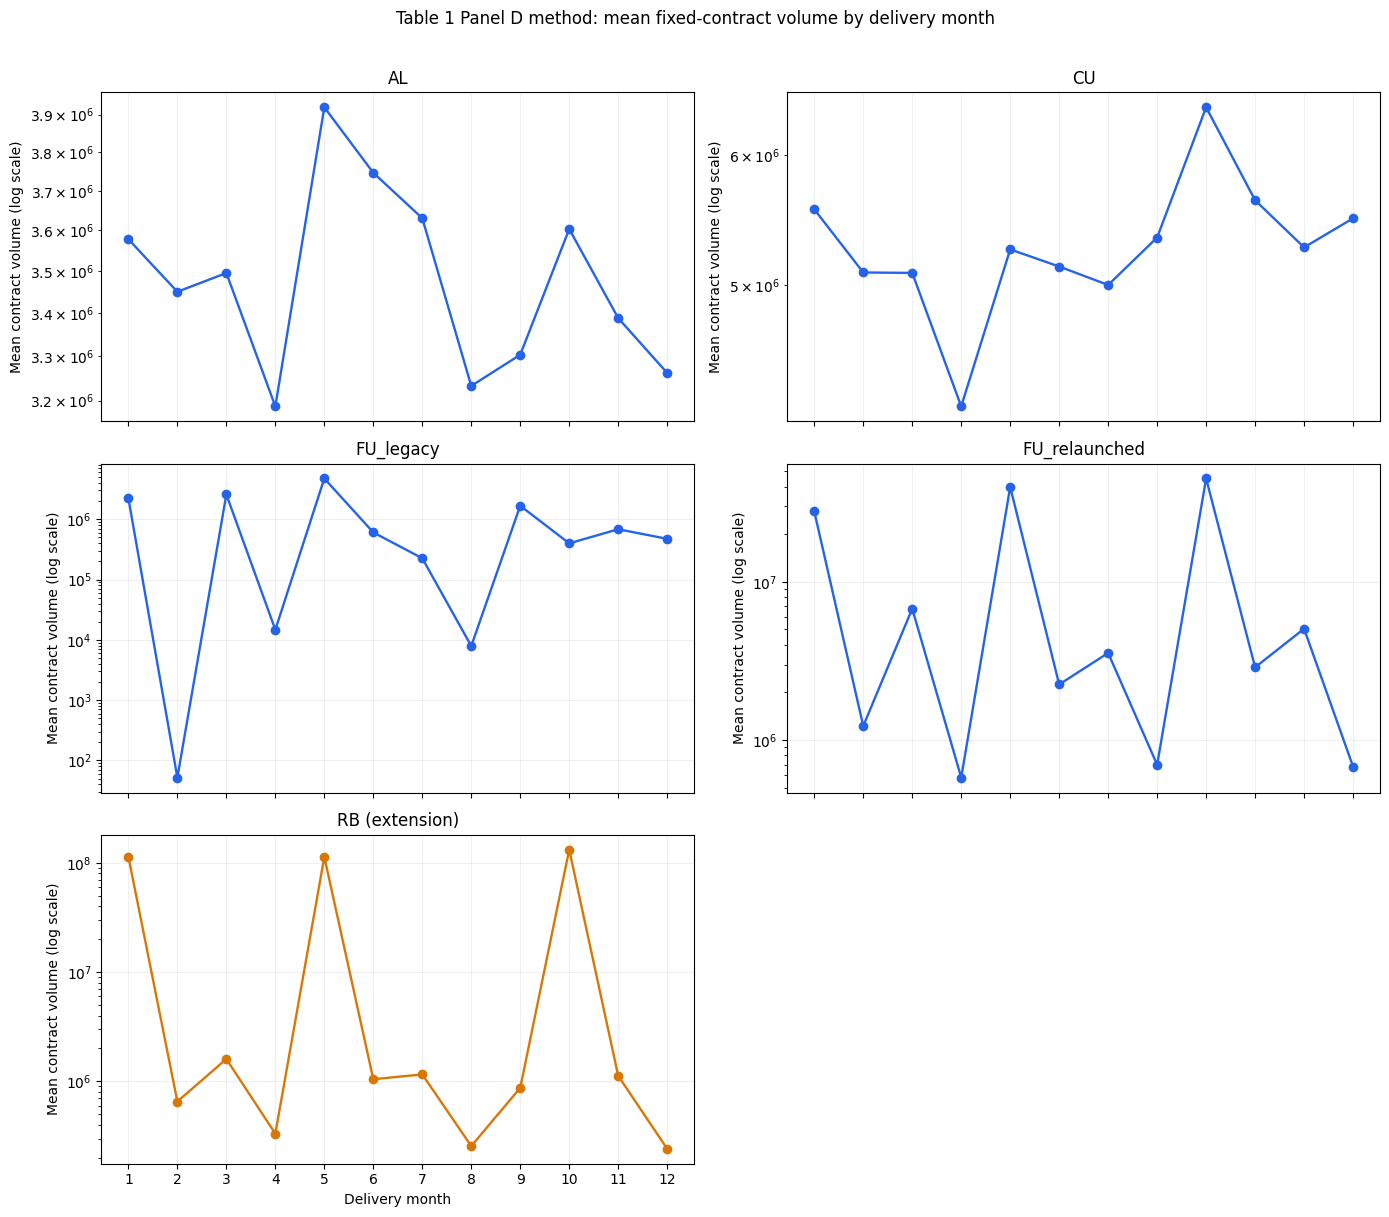

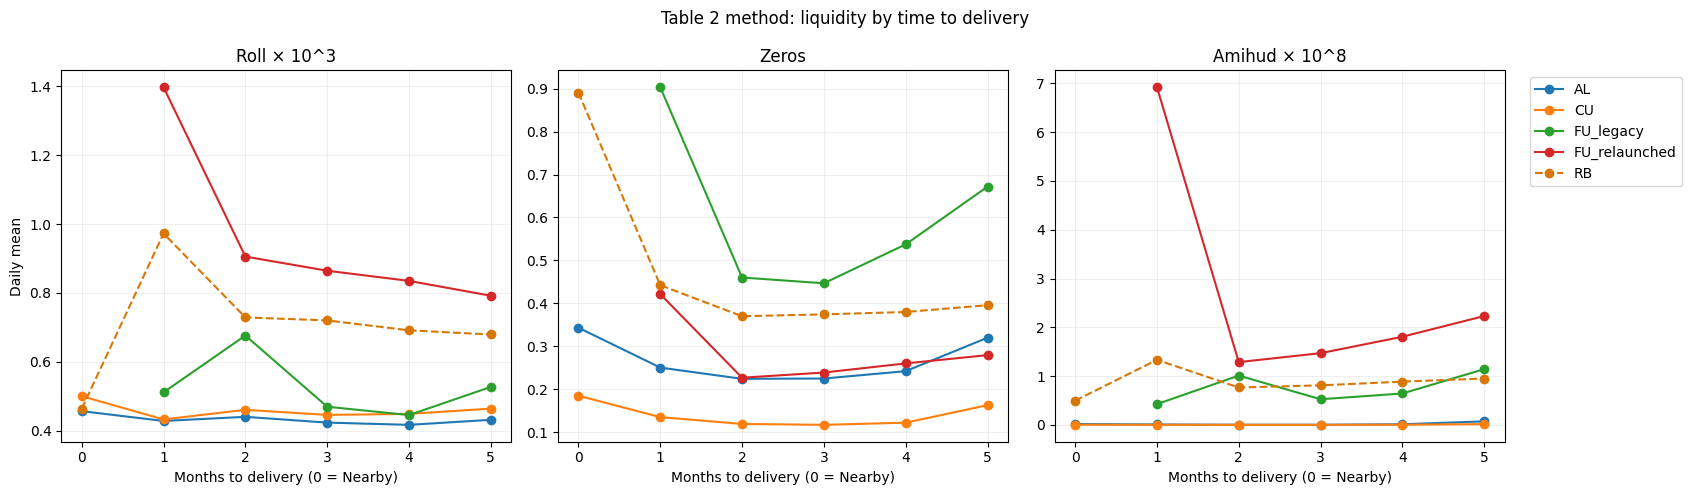

In [11]:
figure, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)
for axis, series_id in zip(axes.flat, series_order):
    series_volume_df = table1_panel_d_df.loc[
        table1_panel_d_df["series_id"] == series_id
    ]
    series_color = "#d97706" if series_id == "RB" else "#2563eb"
    axis.plot(
        series_volume_df["delivery_month"],
        series_volume_df["mean_contracts_traded"],
        marker="o",
        linewidth=1.7,
        color=series_color,
    )
    axis.set_title(
        f"{series_id}"
        + (" (extension)" if series_id == "RB" else "")
    )
    axis.set_yscale("log")
    axis.set_xticks(range(1, 13))
    axis.grid(alpha=0.2)
    axis.set_ylabel("Mean contract volume (log scale)")
axes.flat[-1].axis("off")
for axis in axes[-1, :]:
    axis.set_xlabel("Delivery month")
figure.suptitle(
    "Table 1 Panel D method: mean fixed-contract volume by delivery month",
    y=1.01,
)
figure.tight_layout()
plt.show()

figure, axes = plt.subplots(1, 3, figsize=(17, 5), sharex=True)
for axis, (measure_name, _) in zip(axes, metric_specifications):
    measure_df = table2_tidy_df.loc[
        table2_tidy_df["measure"] == measure_name
    ]
    for series_id in series_order:
        series_measure_df = measure_df.loc[
            measure_df["series_id"] == series_id
        ]
        axis.plot(
            series_measure_df["months_to_delivery"],
            series_measure_df["Mean"],
            marker="o",
            linewidth=1.5,
            linestyle="--" if series_id == "RB" else "-",
            color="#d97706" if series_id == "RB" else None,
            label=series_id,
        )
    axis.set_title(measure_name)
    axis.set_xlabel("Months to delivery (0 = Nearby)")
    axis.grid(alpha=0.2)
axes[0].set_ylabel("Daily mean")
axes[-1].legend(bbox_to_anchor=(1.04, 1), loc="upper left")
figure.suptitle("Table 2 method: liquidity by time to delivery")
figure.tight_layout()
plt.show()

In [12]:
best_liquidity_row_indexes = (
    table2_tidy_df.groupby(
        ["series_id", "measure"],
        observed=True,
    )["Mean"].idxmin()
)
best_liquidity_df = (
    table2_tidy_df.loc[
        best_liquidity_row_indexes,
        [
            "series_id",
            "measure",
            "months_to_delivery",
            "Mean",
            "observations",
        ],
    ]
    .sort_values(["series_id", "measure"])
    .reset_index(drop=True)
)
best_liquidity_df["paper_three_month_pattern"] = (
    best_liquidity_df["months_to_delivery"].eq(3)
)

highest_volume_row_indexes = (
    table1_panel_d_df.groupby(
        "series_id",
        observed=True,
    )["mean_contracts_traded"].idxmax()
)
highest_volume_month_df = (
    table1_panel_d_df.loc[
        highest_volume_row_indexes,
        [
            "series_id",
            "delivery_month",
            "mean_contracts_traded",
            "delivery_contract_count",
        ],
    ]
    .sort_values("series_id")
    .reset_index(drop=True)
)

display(best_liquidity_df.round(6))
display(highest_volume_month_df.round(2))

interpretation_lines = []
for series_id in series_order:
    series_best_df = best_liquidity_df.loc[
        best_liquidity_df["series_id"] == series_id
    ]
    metric_text = "；".join(
        f"{row.measure}: {int(row.months_to_delivery)} 个月"
        for row in series_best_df.itertuples(index=False)
    )
    interpretation_lines.append(f"- **{series_id}**：{metric_text}")

three_month_match_count = int(
    best_liquidity_df["paper_three_month_pattern"].sum()
)
interpretation_markdown = f"""
### 样本内读数

以下是三个指标各自“均值最低”的到期距离；它不是把三项指标任意加权后的综合排名：

{chr(10).join(interpretation_lines)}

共 {len(best_liquidity_df)} 个“序列 × 指标”组合中，
{three_month_match_count} 个组合在 3 个月处取得最低均值。论文原样本中 AL、CU、FU
均呈现 3 个月最流动；本项目只把上述湖仓结果与该方向比较，不把差异解释为复现失败。
RB 是论文外扩展，不能混入论文结论。
"""
display(Markdown(interpretation_markdown))

,series_id,measure,months_to_delivery,Mean,observations,paper_three_month_pattern
0,AL,Amihud × 10^8,3,0.002812,4044,True
1,AL,Roll × 10^3,4,0.416711,4045,False
2,AL,Zeros,2,0.224145,4045,False
3,CU,Amihud × 10^8,2,0.000502,4044,False
4,CU,Roll × 10^3,1,0.432388,4045,False
5,CU,Zeros,3,0.116951,4045,True
6,FU_legacy,Amihud × 10^8,1,0.425532,277,False
7,FU_legacy,Roll × 10^3,4,0.445104,389,False
8,FU_legacy,Zeros,3,0.446700,404,True
9,FU_relaunched,Amihud × 10^8,2,1.286586,1613,False


,series_id,delivery_month,mean_contracts_traded,delivery_contract_count
0,AL,5,3.919693e+06,17
1,CU,9,6.416887e+06,17
2,FU_legacy,5,4.731526e+06,2
3,FU_relaunched,9,4.499760e+07,7
4,RB,10,1.315864e+08,17



### 样本内读数

以下是三个指标各自“均值最低”的到期距离；它不是把三项指标任意加权后的综合排名：

- **AL**：Amihud × 10^8: 3 个月；Roll × 10^3: 4 个月；Zeros: 2 个月
- **CU**：Amihud × 10^8: 2 个月；Roll × 10^3: 1 个月；Zeros: 3 个月
- **FU_legacy**：Amihud × 10^8: 1 个月；Roll × 10^3: 4 个月；Zeros: 3 个月
- **FU_relaunched**：Amihud × 10^8: 2 个月；Roll × 10^3: 5 个月；Zeros: 2 个月
- **RB**：Amihud × 10^8: 0 个月；Roll × 10^3: 0 个月；Zeros: 2 个月

共 15 个“序列 × 指标”组合中，
3 个组合在 3 个月处取得最低均值。论文原样本中 AL、CU、FU
均呈现 3 个月最流动；本项目只把上述湖仓结果与该方向比较，不把差异解释为复现失败。
RB 是论文外扩展，不能混入论文结论。


## 9. 独立验证门禁

In [13]:
expected_bounds_df = (
    expected_sample_df.groupby("series_id", observed=True)["trading_date"]
    .agg(actual_start="min", actual_end="max")
    .reset_index()
    .merge(
        sample_spec_df[
            ["series_id", "sample_start", "sample_end"]
        ],
        on="series_id",
        validate="one_to_one",
    )
)
observed_distance_sets = (
    complete_contract_day_df.groupby(
        "series_id",
        observed=True,
    )["months_to_delivery"]
    .agg(lambda values: set(pd.to_numeric(values).astype(int)))
    .to_dict()
)
expected_distance_sets = {
    "AL": set(range(6)),
    "CU": set(range(6)),
    "FU_legacy": set(range(1, 6)),
    "FU_relaunched": set(range(1, 6)),
    "RB": set(range(6)),
}
fu_legacy_last_date = daily_liquidity_df.loc[
    daily_liquidity_df["series_id"] == "FU_legacy",
    "trading_date",
].max()
fu_relaunched_first_date = daily_liquidity_df.loc[
    daily_liquidity_df["series_id"] == "FU_relaunched",
    "trading_date",
].min()

finite_roll_mask = np.isfinite(
    daily_liquidity_df["roll_effective_spread"]
)
finite_zero_mask = np.isfinite(
    daily_liquidity_df["zero_return_proportion"]
)
finite_amihud_mask = daily_liquidity_df[
    "amihud_illiquidity"
].isna() | np.isfinite(daily_liquidity_df["amihud_illiquidity"])

validation_gate_df = pd.DataFrame(
    [
        (
            "latitude_environment",
            current_python == expected_python,
            str(current_python),
        ),
        (
            "source_schema_physical_compatibility",
            source_contract_audit_df[
                "physical_mismatch_count"
            ].eq(0).all(),
            ", ".join(source_contract_audit_df["table_name"]),
        ),
        (
            "fixed_series_and_sample_endpoints",
            set(expected_sample_df["series_id"])
            == set(sample_spec_df["series_id"])
            and (
                expected_bounds_df["actual_start"]
                == expected_bounds_df["sample_start"]
            ).all()
            and (
                expected_bounds_df["actual_end"]
                == expected_bounds_df["sample_end"]
            ).all(),
            "五个序列均保持冻结起止日",
        ),
        (
            "delivery_distance_classification",
            observed_distance_sets == expected_distance_sets,
            str(observed_distance_sets),
        ),
        (
            "day_sessions_only",
            not candidate_session_df["is_night_session"].any()
            and not bar_calendar_df["is_night_session"].any(),
            "合约日历与 bar calendar 在读取时排除夜盘",
        ),
        (
            "upstream_bar_keys_complete",
            candidate_bar_session_df["_merge"].eq("both").all()
            and complete_contract_day_df[
                "is_complete_contract_day"
            ].all(),
            (
                f"{len(complete_contract_day_df):,} 个候选合约日，"
                "均有 3 Session / 225 分钟正式完成证据"
            ),
        ),
        (
            "minute_rows_align_to_upstream_evidence",
            minute_read_audit_df[
                "session_alignment_failures"
            ].eq(0).all()
            and minute_read_audit_df[
                "selected_day_minute_rows"
            ].sum()
            == minute_read_audit_df[
                "expected_day_minute_rows"
            ].sum(),
            (
                f"{int(minute_read_audit_df['selected_day_minute_rows'].sum()):,}"
                " 个日盘分钟行"
            ),
        ),
        (
            "session_open_return_anchor",
            minute_read_audit_df["session_open_anchors"].sum()
            == len(complete_session_keys_df),
            "每个 Session 首分钟用本 Session 开盘价锚定",
        ),
        (
            "five_minute_and_roll_pair_counts",
            daily_liquidity_df[
                "five_minute_interval_count"
            ].eq(45).all()
            and daily_liquidity_df["roll_pair_count"].eq(42).all(),
            "45 个五分钟区间；3 个 Session 内共 42 个 Roll 相邻对",
        ),
        (
            "volume_coverage_and_nonnegativity",
            daily_liquidity_df["daily_volume"].dropna().ge(0).all()
            and table2_coverage_df["volume_valid_days"].le(
                table2_coverage_df["contract_days"]
            ).all(),
            (
                f"有效成交量日 {int(daily_liquidity_df['daily_volume'].count()):,}"
                f" / {len(daily_liquidity_df):,}"
            ),
        ),
        (
            "zero_return_bounds",
            finite_zero_mask.all()
            and daily_liquidity_df[
                "zero_return_proportion"
            ].between(0, 1).all(),
            "Zeros 使用 0—1 比例",
        ),
        (
            "roll_finite_and_nonnegative",
            finite_roll_mask.all()
            and daily_liquidity_df[
                "roll_effective_spread"
            ].ge(0).all(),
            "协方差非负时 Roll 明确置 0",
        ),
        (
            "amihud_denominator_and_nonnegativity",
            finite_amihud_mask.all()
            and daily_liquidity_df[
                "amihud_illiquidity"
            ].dropna().ge(0).all()
            and daily_liquidity_df[
                "valid_amihud_interval_count"
            ].between(0, 45).all(),
            (
                "只对五分钟 money > 0 且五个分钟分母完整的区间取均值；"
                f"有效日 {int(daily_liquidity_df['amihud_illiquidity'].count()):,}"
            ),
        ),
        (
            "published_table_scaling",
            np.allclose(
                daily_liquidity_df["roll_x1e3"],
                daily_liquidity_df[
                    "roll_effective_spread"
                ]
                * 1e3,
            )
            and np.allclose(
                daily_liquidity_df["amihud_x1e8"].dropna(),
                daily_liquidity_df[
                    "amihud_illiquidity"
                ].dropna()
                * 1e8,
            ),
            "Roll × 10^3；Amihud × 10^8；Zeros 不乘 100",
        ),
        (
            "fu_segments_are_independent",
            fu_legacy_last_date < fu_relaunched_first_date,
            (
                f"legacy_end={fu_legacy_last_date.date()}, "
                f"relaunched_start={fu_relaunched_first_date.date()}"
            ),
        ),
        (
            "rb_extension_is_separate",
            sample_spec_df.loc[
                sample_spec_df["series_id"] == "RB",
                "research_role",
            ].eq("论文外扩展品种").all()
            and "RB" in table1_panel_d_df["series_id"].unique()
            and "RB" in table2_tidy_df["series_id"].unique(),
            "RB 单列，不并入论文品种标签",
        ),
    ],
    columns=["gate", "passed", "evidence"],
)
display(validation_gate_df)
assert validation_gate_df["passed"].all(), validation_gate_df.loc[
    ~validation_gate_df["passed"]
]

,gate,passed,evidence
0,latitude_environment,True,E:\anaconda3\envs\latitude\python.exe
1,source_schema_physical_compatibility,True,"dim_futures_variety_calendar, dim_futures_contract_calendar, dim_futures_bar_calendar, fact_futures_minute"
2,fixed_series_and_sample_endpoints,True,五个序列均保持冻结起止日
3,delivery_distance_classification,True,"{'AL': {0, 1, 2, 3, 4, 5}, 'CU': {0, 1, 2, 3, 4, 5}, 'FU_legacy': {1, 2, 3, 4, 5}, 'FU_relaunched': {1, 2, 3, 4, 5}, 'RB': {0, 1, 2, 3, 4, 5}}"
4,day_sessions_only,True,合约日历与 bar calendar 在读取时排除夜盘
5,upstream_bar_keys_complete,True,"76,555 个候选合约日，均有 3 Session / 225 分钟正式完成证据"
6,minute_rows_align_to_upstream_evidence,True,"17,224,875 个日盘分钟行"
7,session_open_return_anchor,True,每个 Session 首分钟用本 Session 开盘价锚定
8,five_minute_and_roll_pair_counts,True,45 个五分钟区间；3 个 Session 内共 42 个 Roll 相邻对
9,volume_coverage_and_nonnegativity,True,"有效成交量日 76,555 / 76,555"


## 10. 结果解释边界与限制

1. 这是 JQData 正式湖仓、2010 年以后样本的方法复现，不是 GTA 数值复刻。
2. 论文历史日盘按 4 小时形成 48 个五分钟区间；本项目用三个真实日盘 Session 的 225 分钟，固定形成 45 个区间，不填补晨休。
3. Roll 将附录公式中的价格变化实现为五分钟对数价格变化，以匹配论文 Table 2 的量级和跨品种可比性；相邻变化只在 Session 内配对，所以一天是 42 对，并主动排除晨休和午休价差。
4. Table 1 Panel D 的“平均成交合约数”采用可审计的合约窗口总量定义；样本首尾合约可能只覆盖部分 0—5 月窗口，表中同时给出平均观察日和成交量日覆盖率。
5. Nearby 只在交割当月合约仍实际挂牌交易的日期出现。FU 两段样本都没有 Nearby 合约日，因此保持缺失，不用 1 个月合约代替。
6. Amihud 的 RMB 分母直接使用正式分钟事实 `money`；`money <= 0` 或五个分钟分母不完整的五分钟区间不参与均值，覆盖率已独立报告。
7. 本项的流动性结论只用于描述 0—5 月截面；后续固定三个月合约序列仍按项目 README 的“交易月后第 3 个月交割”冻结规则构造。